## EPA air quality data analysis 

In [26]:
import pandas as pd
import pdb
import numpy as np
import matplotlib.pyplot as plt
import hvplot.pandas

In [27]:
# read site listing data  - https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
sites = pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/aqs_sites.zip')

In [28]:
print(type(sites))
print(sites.shape)
sites.columns

<class 'pandas.core.frame.DataFrame'>
(20952, 28)


Index(['State Code', 'County Code', 'Site Number', 'Latitude', 'Longitude',
       'Datum', 'Elevation', 'Land Use', 'Location Setting',
       'Site Established Date', 'Site Closed Date', 'Met Site State Code',
       'Met Site County Code', 'Met Site Site Number', 'Met Site Type',
       'Met Site Distance', 'Met Site Direction', 'GMT Offset',
       'Owning Agency', 'Local Site Name', 'Address', 'Zip Code', 'State Name',
       'County Name', 'City Name', 'CBSA Name', 'Tribe Name',
       'Extraction Date'],
      dtype='object')

In [29]:
# use bitwise operators
# & for and 
# | for or 
#a= sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a= sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'New York'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a

,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12387,36,61,1,URBAN AND CENTER CITY,New York,New York,New York
12388,36,61,2,URBAN AND CENTER CITY,New York,New York,New York
12389,36,61,5,URBAN AND CENTER CITY,New York,New York,New York
12390,36,61,10,URBAN AND CENTER CITY,New York,New York,New York
12391,36,61,13,URBAN AND CENTER CITY,New York,New York,New York
12392,36,61,14,URBAN AND CENTER CITY,New York,New York,New York
12393,36,61,23,URBAN AND CENTER CITY,New York,New York,New York
12394,36,61,24,URBAN AND CENTER CITY,New York,New York,New York
12395,36,61,37,URBAN AND CENTER CITY,New York,New York,New York
12396,36,61,50,URBAN AND CENTER CITY,New York,New York,New York


In [30]:
# use bitwise operators
# & for and 
# | for or 
# a= sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a= sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'Queens'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a

,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12556,36,81,4,URBAN AND CENTER CITY,New York,Queens,New York
12557,36,81,8,SUBURBAN,New York,Queens,New York
12558,36,81,15,SUBURBAN,New York,Queens,New York
12559,36,81,16,SUBURBAN,New York,Queens,New York
12560,36,81,20,URBAN AND CENTER CITY,New York,Queens,New York
12561,36,81,26,URBAN AND CENTER CITY,New York,Queens,New York
12562,36,81,29,SUBURBAN,New York,Queens,New York
12563,36,81,30,SUBURBAN,New York,Queens,New York
12564,36,81,40,URBAN AND CENTER CITY,New York,Queens,New York
12565,36,81,41,URBAN AND CENTER CITY,New York,Queens,New York


# Site to download air quality data  
# https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI

In [31]:
pm25_daily_2020=pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2020.zip')

In [32]:
pm25_daily_2020

,State Name,county Name,State Code,County Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,Alabama,Baldwin,1,3,2020-01-01,56,Moderate,PM2.5,01-003-0010,1
1,Alabama,Baldwin,1,3,2020-01-04,18,Good,PM2.5,01-003-0010,1
2,Alabama,Baldwin,1,3,2020-01-07,18,Good,PM2.5,01-003-0010,1
3,Alabama,Baldwin,1,3,2020-01-10,51,Moderate,PM2.5,01-003-0010,1
4,Alabama,Baldwin,1,3,2020-01-13,38,Good,PM2.5,01-003-0010,1
...,...,...,...,...,...,...,...,...,...,...
325133,Wyoming,Weston,56,45,2020-12-27,32,Good,Ozone,56-045-0003,1
325134,Wyoming,Weston,56,45,2020-12-28,30,Good,Ozone,56-045-0003,1
325135,Wyoming,Weston,56,45,2020-12-29,33,Good,Ozone,56-045-0003,1
325136,Wyoming,Weston,56,45,2020-12-30,33,Good,Ozone,56-045-0003,1


In [33]:
pm25_daily_2020.columns

Index(['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI',
       'Category', 'Defining Parameter', 'Defining Site',
       'Number of Sites Reporting'],
      dtype='object')

In [10]:
pm25_daily_2020.head(10)

,CBSA,CBSA Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,"Aberdeen, SD",10100,2020-01-01,27,Good,PM2.5,46-013-0004,1
1,"Aberdeen, SD",10100,2020-01-02,47,Good,PM2.5,46-013-0004,1
2,"Aberdeen, SD",10100,2020-01-03,29,Good,PM2.5,46-013-0004,1
3,"Aberdeen, SD",10100,2020-01-04,52,Moderate,PM2.5,46-013-0004,1
4,"Aberdeen, SD",10100,2020-01-05,18,Good,PM2.5,46-013-0004,1
5,"Aberdeen, SD",10100,2020-01-06,31,Good,PM2.5,46-013-0004,1
6,"Aberdeen, SD",10100,2020-01-07,21,Good,PM2.5,46-013-0004,1
7,"Aberdeen, SD",10100,2020-01-08,31,Good,PM2.5,46-013-0004,1
8,"Aberdeen, SD",10100,2020-01-09,43,Good,PM2.5,46-013-0004,1
9,"Aberdeen, SD",10100,2020-01-10,29,Good,PM2.5,46-013-0004,1


In [ ]:
pm25_daily_2020.info()

In [22]:
pm25_daily_2020.columns
#pm25_daily_2020.index
#pm25_daily_2020.values

Index(['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI',
       'Category', 'Defining Parameter', 'Defining Site',
       'Number of Sites Reporting'],
      dtype='object')

In [34]:
pm25_NY_2020 = pm25_daily_2020.loc[(pm25_daily_2020['county Name']== 'New York'), ['State Name', 'county Name', 'Date', 'AQI']]
pm25_NY_2020

,State Name,county Name,Date,AQI
185246,New York,New York,2020-01-01,48
185247,New York,New York,2020-01-02,61
185248,New York,New York,2020-01-03,67
185249,New York,New York,2020-01-04,61
185250,New York,New York,2020-01-05,49
...,...,...,...,...
185607,New York,New York,2020-12-27,52
185608,New York,New York,2020-12-28,52
185609,New York,New York,2020-12-29,52
185610,New York,New York,2020-12-30,34


<Axes: xlabel='Date'>

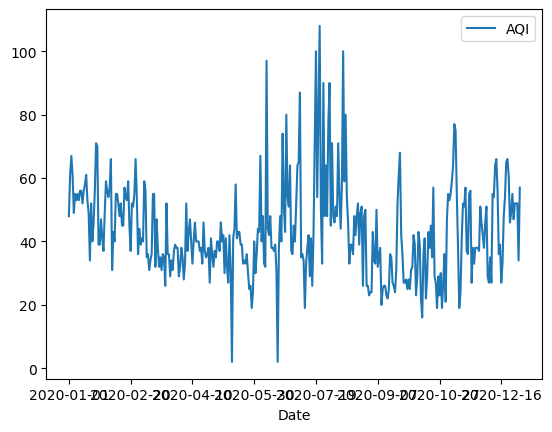

In [35]:
pm25_NY_2020.plot(x='Date', y='AQI')